# Model 8 — Insurance Premium Estimator (Linear Regression)

## Question
> Given a car's technical specifications and damage history — what average insurance (kasko) premium should the owner expect to pay?

## Introduction
This notebook builds a **regression model** to predict average kasko (insurance) premiums.

- **Dataset**: Unscaled data (`proceed_dataset_without_scaling.csv`)
- **Target variable**: `Ortalama Kasko` (average insurance premium in TL)
- **Algorithm options**: You may use `LinearRegression`, `Ridge`, `Lasso`, or even tree-based/ensemble methods for this task.
- **Special note**: If `paint_damage_score` and `total_changed_parts` appear as strong coefficients/importances, it validates Team 3's engineered damage features — be sure to highlight this in your presentation.
- **Feature flexibility**: You may choose different features, add new features, or tune hyperparameters — but you cannot change the general technique category.

### 1. Data Import

The cell below loads all required libraries and the dataset. **Run this cell as-is** — it is provided and complete.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")

target_col = 'Ortalama Kasko'
if target_col in df.columns:
    print(f"Target column '{target_col}': {df[target_col].notna().sum()} non-null values")
    print(f"Range: {df[target_col].min():,.0f} — {df[target_col].max():,.0f} TL")
else:
    print(f"WARNING: Target column '{target_col}' not found.")
    print(f"Available columns: {[c for c in df.columns if 'Kasko' in c or 'kasko' in c]}")


Dataset shape: (2589, 87)
Target column 'Ortalama Kasko': 2589 non-null values
Range: 9 — 11 TL


### 2. Feature Selection

**TODO — Student task:** Review the recommended features below. You may keep them, remove some, or add others from the dataset. After finalizing your features, run this cell to prepare training and test sets.

In [31]:
# 🔹 Araç yaşı oluştur
df["Araç Yaşı"] = 2026 - df["Yıl"]

features = [
    "Araç Yaşı",
    "Kilometre",
    "Motor Gücü",
    "Motor Hacmi",
    "Maksimum Hız",
    "Hızlanma (0-100)",

    # 🔥 Hasar özellikleri (en önemli grup)
    "paint_damage_score",
    "total_changed_parts",
    "is_fully_original",
]

# 🔹 Kasa tipi ekle
features += [col for col in df.columns if "Kasa Tipi_" in col]

# 🔹 Çekiş tipi ekle (güçlü feature)
features += [col for col in df.columns if "Çekiş_" in col]

# 🔹 Yakıt tipi ekle (risk/kasko etkiler)
features += [col for col in df.columns if "Yakıt Tipi_" in col]

# 🔹 X ve y
X = df[features]
y = df["Ortalama Kasko"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # %80 train - %20 test
    random_state=42     # aynı sonucu almak için
)

### 3. Model Training

**TODO — Student task:** This cell is a placeholder. The structure (instantiate → fit → predict) is correct — you may change the model type or tune hyperparameters.

In [34]:
from sklearn.linear_model import LinearRegression  # You may also try Ridge, Lasso, or even ensemble methods

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


### 4. Evaluation Metrics

The cell below computes RMSE, MAE, and R² on the test set. These are the primary metrics for your report.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

In [37]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f} TL")
print(f"MAE:  {mae:,.2f} TL")
print(f"R²:   {r2:.4f}")

RMSE: 0.12 TL
MAE:  0.08 TL
R²:   0.3428


### metrik değerleri garip çıktı çünkü veri ön işlemede outlier değerler için log dönüşümü yapmıştık. şimdi daha normal sonuçlar alabilmek için,

## log dönüşümünü geri alıyorum


In [38]:
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

In [39]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f} TL")
print(f"MAE:  {mae:,.2f} TL")
print(f"R²:   {r2:.4f}")

RMSE: 2,996.70 TL
MAE:  1,347.16 TL
R²:   0.3428


şimdi sonuçlar daha anlaşılır.. modelin ortalama mutlak hatası 1347 TL (MAE).
tahminde 3000 tl civarında sapma yapıyor (RMSE)
ve model veri setinin %34'nü anlıyor (R2)



> Modelin performansı düşük



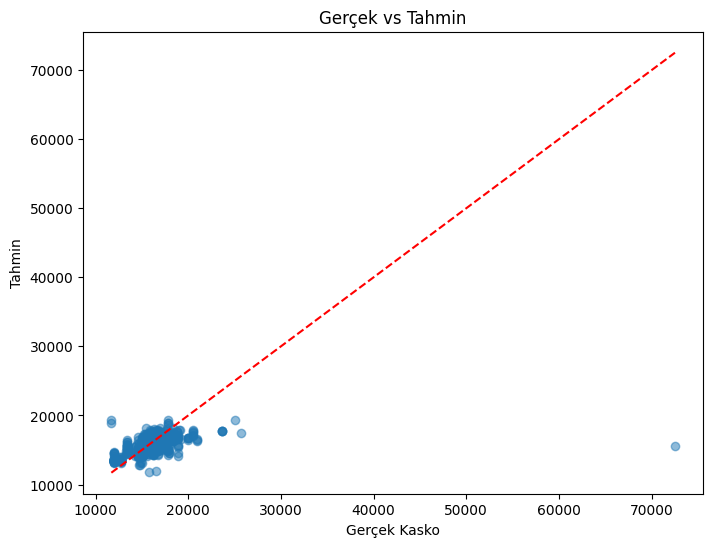

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test_real, y_pred_real, alpha=0.5)
plt.xlabel("Gerçek Kasko")
plt.ylabel("Tahmin")
plt.title("Gerçek vs Tahmin")

plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    'r--'
)

plt.show()

## Modelin performansı neden düşük?


*   Log dönüşümünü geri alınca outlier değerler de geri geldi.


> Scatter tablosundan da anladığımız gibi, kasko düşükken modelin tahmini iyi ama fiyat yükseldikçe yanlış tahmin yapıyor..


*   Features yeterli değil, geliştirilmesi gerek



In [42]:
# 🔹 1. Outlier temizliği (%1 üstünü at)
df = df[df["Ortalama Kasko"] < df["Ortalama Kasko"].quantile(0.99)].copy()

In [44]:
df["Yaş_KM"] = df["Araç Yaşı"] * df["Kilometre"]
df["Güç_Hacmi"] = df["Motor Gücü"] * df["Motor Hacmi"]
df["Hasar_Oranı"] = df["paint_damage_score"] / (df["total_changed_parts"] + 1)

features += ["Yaş_KM", "Güç_Hacmi", "Hasar_Oranı"]

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

In [46]:
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f} TL")
print(f"MAE:  {mae:,.2f} TL")
print(f"R²:   {r2:.4f}")

RMSE: 815.01 TL
MAE:  500.21 TL
R²:   0.8078


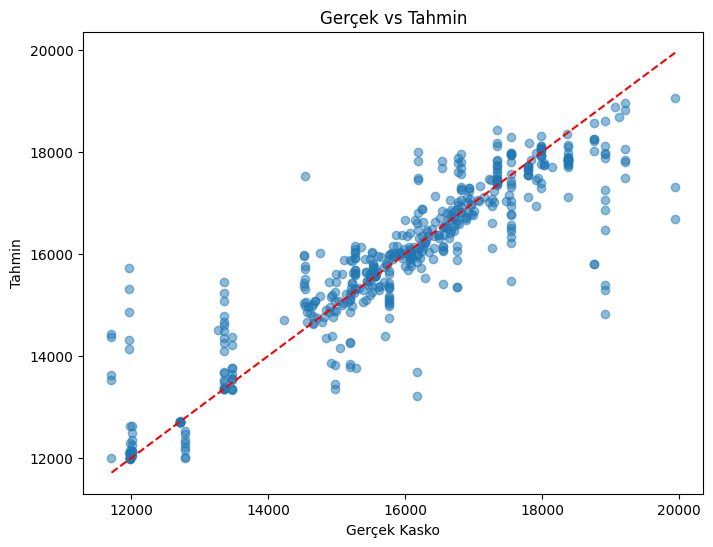

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test_real, y_pred_real, alpha=0.5)
plt.xlabel("Gerçek Kasko")
plt.ylabel("Tahmin")
plt.title("Gerçek vs Tahmin")

plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    'r--'
)

plt.show()

### Performans çok daha iyi..

## Modelin

### 5. Actual vs Predicted Scatter Plot

This scatter plot compares actual kasko premiums with model predictions. Points close to the red diagonal line indicate accurate predictions.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

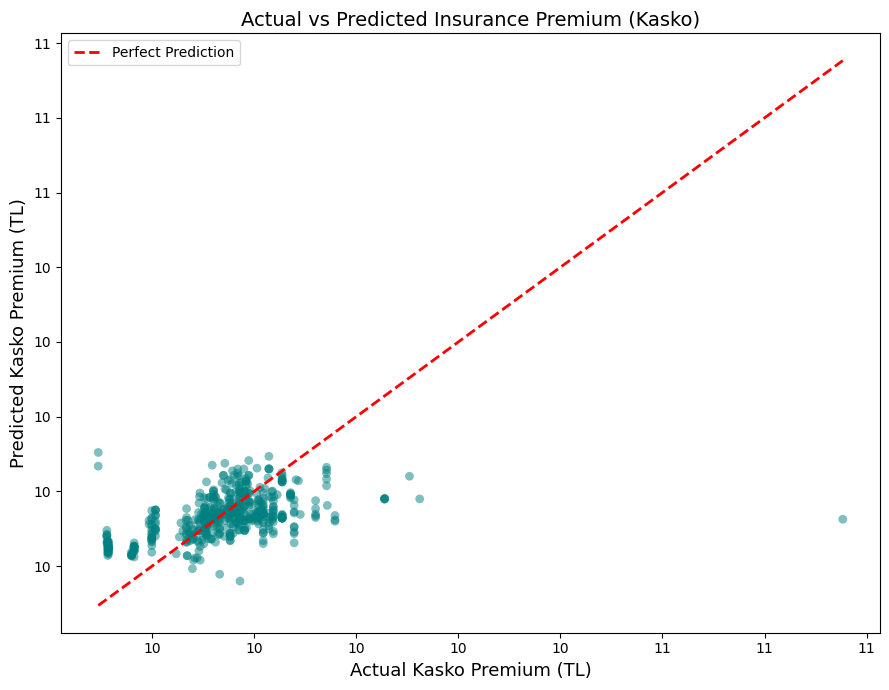

In [ ]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_test, y_pred, alpha=0.5, color='teal', s=40, edgecolors='none')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Kasko Premium (TL)', fontsize=13)
ax.set_ylabel('Predicted Kasko Premium (TL)', fontsize=13)
ax.set_title('Actual vs Predicted Insurance Premium (Kasko)', fontsize=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

### 6. Feature Importance by Absolute Coefficient

This bar chart ranks features by the absolute value of their coefficient (or feature importance for tree-based models). Red bars increase the premium; green bars decrease it.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

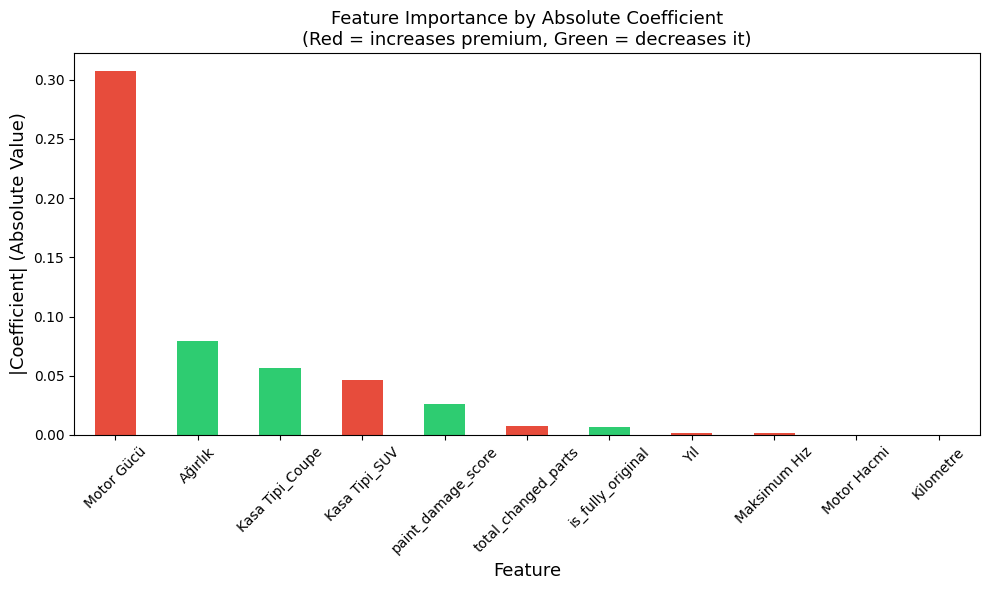

In [ ]:
# ⚠️ Replace model and features with your actual trained model after training.
# Note: This works for LinearRegression/Ridge/Lasso. For tree-based, use feature_importances_ instead.
if hasattr(model, 'coef_'):
    coef_series = pd.Series(np.abs(model.coef_), index=features).sort_values(ascending=False)
    signed_coefs = pd.Series(model.coef_, index=features)
    colors = ['#e74c3c' if signed_coefs[f] > 0 else '#2ecc71' for f in coef_series.index]

    fig, ax = plt.subplots(figsize=(10, 6))
    coef_series.plot(kind='bar', ax=ax, color=colors)
    ax.set_xlabel('Feature', fontsize=13)
    ax.set_ylabel('|Coefficient| (Absolute Value)', fontsize=13)
    ax.set_title('Feature Importance by Absolute Coefficient\n(Red = increases premium, Green = decreases it)', fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Model does not have coef_ attribute. Use feature_importances_ for tree-based models.")

### 7. Original vs Non-Original Car Premium Comparison

This bar chart shows how being fully original vs having replaced parts affects the predicted insurance premium. This directly links to Team 3's damage engineering work.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

/tmp/ipykernel_1087/4238783620.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


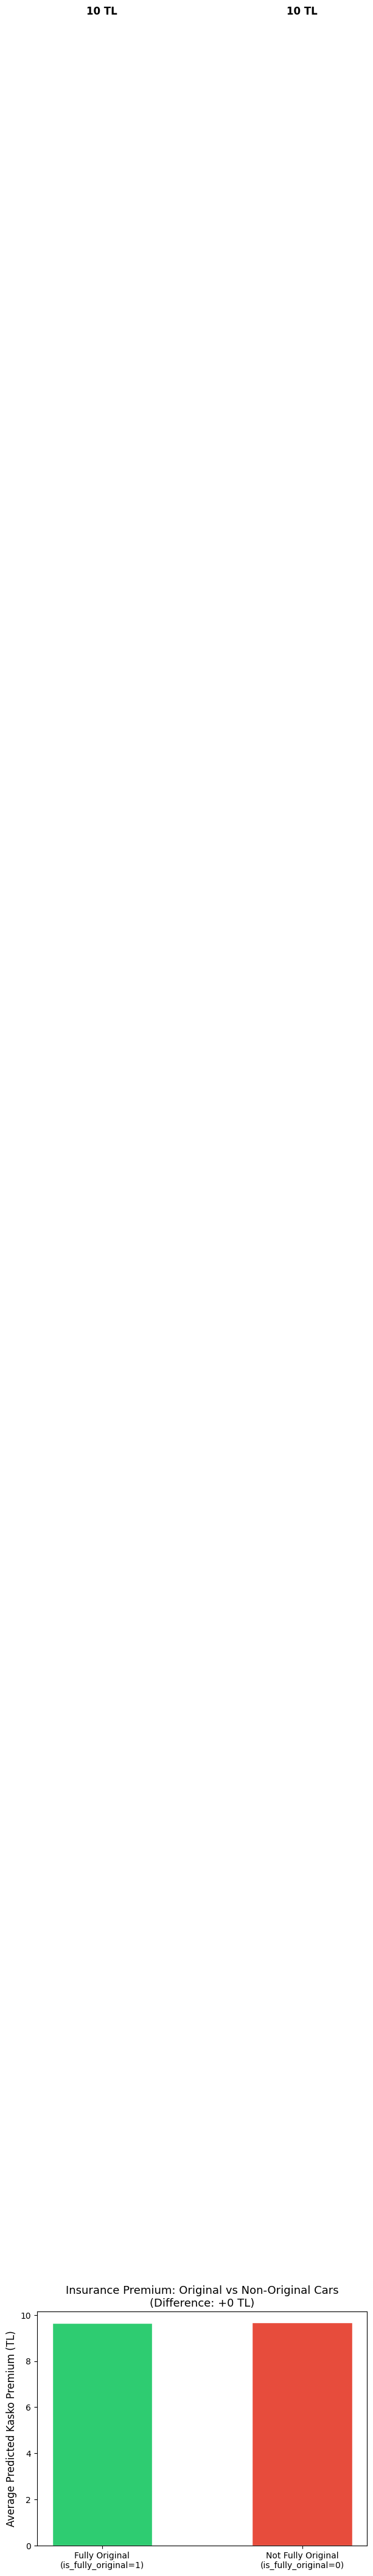


Being non-original is associated with a predicted premium difference of: +0 TL


In [ ]:
# ⚠️ Replace model with your actual trained model after training.
if 'is_fully_original' in features:
    X_test_copy = X_test.copy()

    X_orig = X_test_copy.copy()
    X_orig['is_fully_original'] = 1
    pred_orig = model.predict(X_orig)

    X_not_orig = X_test_copy.copy()
    X_not_orig['is_fully_original'] = 0
    pred_not_orig = model.predict(X_not_orig)

    avg_orig = pred_orig.mean()
    avg_not_orig = pred_not_orig.mean()
    diff = avg_not_orig - avg_orig

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(['Fully Original\n(is_fully_original=1)', 'Not Fully Original\n(is_fully_original=0)'],
                  [avg_orig, avg_not_orig],
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, [avg_orig, avg_not_orig]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,.0f} TL', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Predicted Kasko Premium (TL)', fontsize=12)
    ax.set_title(f'Insurance Premium: Original vs Non-Original Cars\n(Difference: {diff:+,.0f} TL)', fontsize=13)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()
    print(f"\nBeing non-original is associated with a predicted premium difference of: {diff:+,.0f} TL")
else:
    print("'is_fully_original' not in features. Skipping comparison plot.")

### 8. Residual Histogram

This histogram shows the distribution of residuals. A bell-shaped distribution centred near 0 suggests the model errors are approximately normally distributed.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

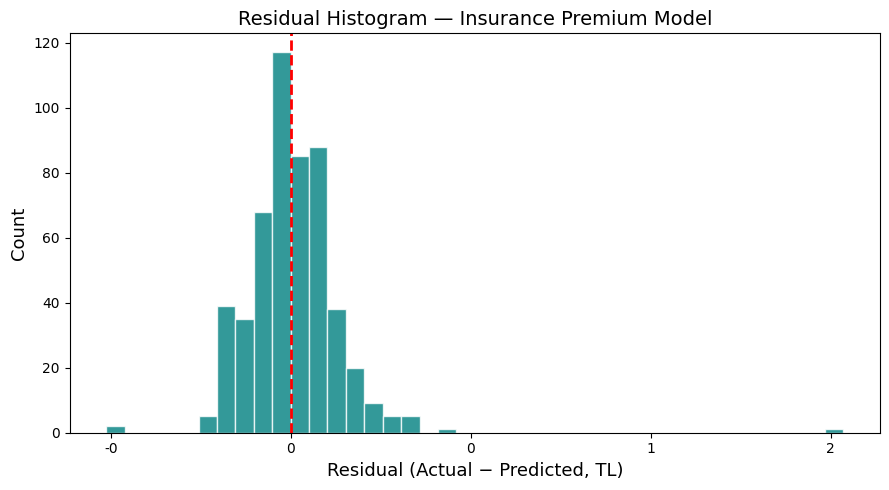

In [ ]:
# ⚠️ Replace y_pred and y_test with your actual outputs after training.
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuals, bins=40, color='teal', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residual (Actual − Predicted, TL)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Residual Histogram — Insurance Premium Model', fontsize=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## ⚠️ If Your Model Underperforms

If your model produces poor results (e.g., low R², large RMSE, or premium predictions far from actual values), **do not discard your results**.

- Keep all outputs as-is
- In your presentation, document exactly what you observe
- Write a short hypothesis: Why might the model have failed? (e.g., 'Insurance premiums may depend heavily on factors not in the dataset, such as driver age or location, making prediction from car specs alone inherently noisy')